Shapes: (51915, 18) (12979, 18)
Class counts (train): {0: 25973, 1: 25942}
Accuracy: 0.7009
ROC AUC:  0.7802

Classification report:
               precision    recall  f1-score   support

           0       0.68      0.76      0.72      6493
           1       0.73      0.64      0.68      6486

    accuracy                           0.70     12979
   macro avg       0.70      0.70      0.70     12979
weighted avg       0.70      0.70      0.70     12979



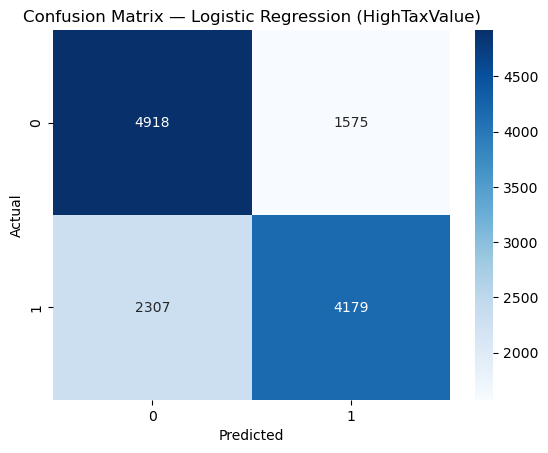

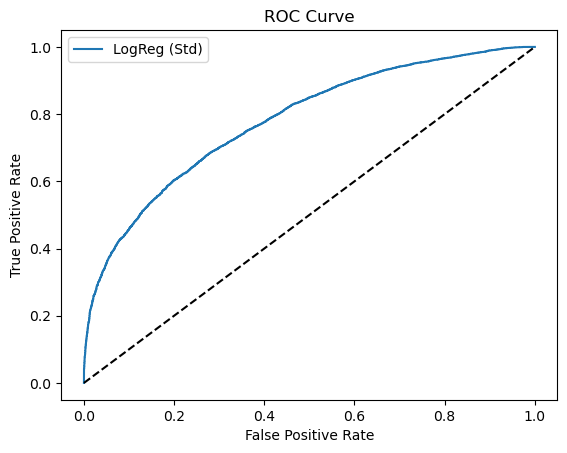

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "zillow_cleaned.csv"

# 1) Load
df = pd.read_csv(CSV_PATH)

# 2) Create binary target from tax value (drop rows with missing tax value first)
df = df.dropna(subset=["taxvaluedollarcnt"]).copy()
median_tax = df["taxvaluedollarcnt"].median()
df["HighTaxValue"] = (df["taxvaluedollarcnt"] > median_tax).astype(int)

# 3) Features: drop the leakage column
TARGET = "HighTaxValue"
X = df.drop(columns=[TARGET, "taxvaluedollarcnt"])
y = df[TARGET]

# 4) Train/test split (stratified for balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shapes:", X_train.shape, X_test.shape)
print("Class counts (train):", dict(zip(*np.unique(y_train, return_counts=True))))

# 5) Preprocess: impute numeric -> standardize numeric
num_sel = selector(dtype_include=['float64','float32','int64','int32'])
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_sel),
    ],
    remainder="drop",   # all your columns are numeric anyway
    n_jobs=-1
)

# 6) Fast logistic regression (saga is scalable)
lr = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(
        solver="saga",
        penalty="l2",
        C=0.5,            # a bit stronger regularization -> faster/stabler
        max_iter=100,
        tol=1e-2,
        random_state=42,
        n_jobs=-1
    ))
])

lr.fit(X_train, y_train)
y_pred  = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

# 7) Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression (HighTaxValue)")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

# 8) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label="LogReg (Std)")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(); plt.show()

In [25]:
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Select numeric columns
num_sel = selector(dtype_include=['float64','float32','int64','int32'])

# Standardization pipeline
pre_std = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Normalization pipeline
pre_norm = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

# Apply transformations
ct_std = ColumnTransformer([("num", pre_std, num_sel)], remainder="drop")
ct_norm = ColumnTransformer([("num", pre_norm, num_sel)], remainder="drop")

X_train_std = ct_std.fit_transform(X_train)
X_test_std  = ct_std.transform(X_test)

X_train_norm = ct_norm.fit_transform(X_train)
X_test_norm  = ct_norm.transform(X_test)

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
import numpy as np

# 1) Pick continuous columns to scale (edit if you want to add/remove)
cont_cols = [
    'bathroomcnt','bedroomcnt','calculatedbathnbr','calculatedfinishedsquarefeet',
    'finishedsquarefeet12','fullbathcnt','latitude','longitude',
    'lotsizesquarefeet','roomcnt','unitcnt','yearbuilt'
]
# Keep only those that actually exist (defensive)
cont_cols = [c for c in cont_cols if c in X_train.columns]

# 2) Preprocess: impute + standardize continuous; pass through the rest unchanged
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cont_cols)
    ],
    remainder="passthrough",
    n_jobs=-1
)

# 3) Fast logistic regression via SGD
sgd_lr = Pipeline(steps=[
    ("pre", pre),
    ("clf", SGDClassifier(
        loss="log_loss",        # logistic regression
        alpha=1e-4,             # L2 strength
        max_iter=2000,
        tol=1e-3,
        early_stopping=False,   # avoids tiny class split issue
        average=True,
        random_state=42
        # class_weight="balanced"  # uncomment if positive/negative counts differ a lot
    ))
])

sgd_lr.fit(X_train, y_train)

# 4) Probabilities (works on sklearn >=1.0). Fallback if not available.
try:
    y_proba = sgd_lr.predict_proba(X_test)[:, 1]
except AttributeError:
    from scipy.special import expit
    y_proba = expit(sgd_lr.decision_function(X_test))

y_pred = (y_proba >= 0.5).astype(int)  # or use sgd_lr.predict(X_test)

LogReg (Standardized) — Accuracy: 0.7009 | ROC AUC: 0.7802

Classification report:
               precision    recall  f1-score   support

           0       0.68      0.76      0.72      6493
           1       0.73      0.64      0.68      6486

    accuracy                           0.70     12979
   macro avg       0.70      0.70      0.70     12979
weighted avg       0.70      0.70      0.70     12979



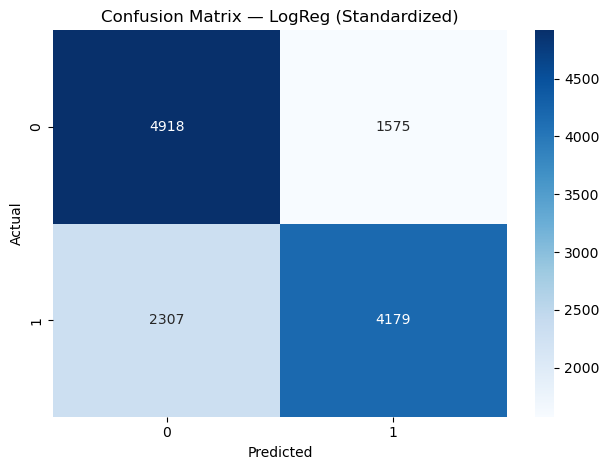

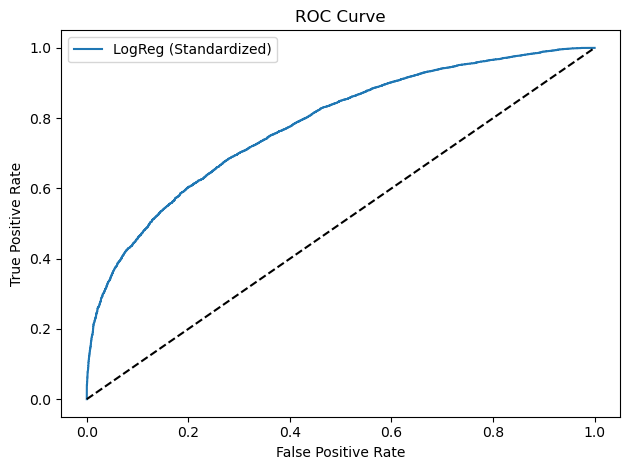

{'accuracy': 0.7009014561984744, 'roc_auc': 0.7802154662729126}

In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, X_test, y_test, name="Model", threshold=0.5, normalize_cm=False):
    """
    model: a fitted sklearn estimator (pipeline ok)
    X_test, y_test: test split
    name: label for plots/print
    threshold: decision threshold for turning probabilities into class labels
    normalize_cm: if True, show normalized confusion matrix
    """
    # Get probabilities (or fall back to decision_function)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        # Some SGD/sklearn versions lack predict_proba
        from scipy.special import expit
        y_score = model.decision_function(X_test)
        y_proba = expit(y_score)

    # Predictions using either model.predict or thresholding
    try:
        y_pred = model.predict(X_test)
    except Exception:
        y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"{name} — Accuracy: {acc:.4f} | ROC AUC: {auc:.4f}\n")
    print("Classification report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true' if normalize_cm else None)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize_cm else "d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=name)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "roc_auc": auc}

# Call with your trained model
evaluate_model(lr, X_test, y_test, name="LogReg (Standardized)")

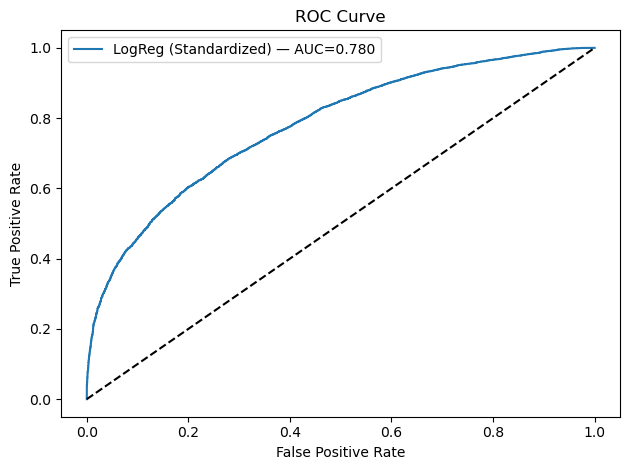

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get predicted probabilities from your trained model
y_proba = lr.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# plot
plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (Standardized) — AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

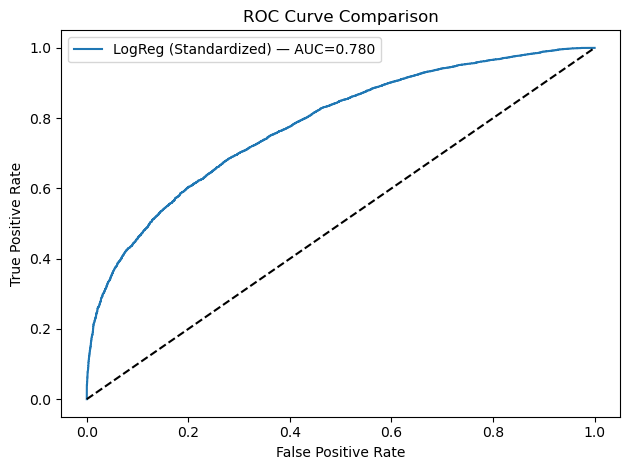

In [35]:
from sklearn.metrics import roc_curve, auc
from scipy.special import expit
import matplotlib.pyplot as plt

def get_proba(model, X):
    # works for both LogisticRegression and SGDClassifier
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # fallback for older SGD: use decision_function -> sigmoid
    return expit(model.decision_function(X))

plt.figure()

# List of models you actually trained
for mdl, name in [
    (lr,     "LogReg (Standardized)"),
    # (lr_norm, "LogReg (MinMax)"),   # uncomment if you trained lr_norm
    # (sgd_lr,  "SGD LogReg (Std)"),  # uncomment if you trained sgd_lr
]:
    y_proba = get_proba(mdl, X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} — AUC={auc(fpr,tpr):.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Week 4: Logistic Regression and Feature Scaling

### 1. Problem Setup
This week I tried out logistic regression on the Zillow dataset. Since logistic regression needs a binary target, I created a new column called `HighTaxValue` that equals 1 if a home’s tax value is above the dataset median and 0 otherwise. I dropped the original `taxvaluedollarcnt` column from the features so there was no leakage. After splitting into train (80%) and test (20%) sets, the classes were very balanced, which is great for this type of model.

---

### 2. Why Feature Scaling?
The features in this dataset are on very different scales. For example, square footage is in the thousands, year built is ~1900–2010, and bathroom counts are usually just single digits. If I don’t scale these, the large numbers can dominate and throw off the regression coefficients. Scaling also helps gradient descent converge faster. That’s why I tested both **standardization** (mean=0, std=1) and **normalization** (range [0,1]).

---

### 3. Modeling
- Preprocessing: median imputation for missing values, then scaling  
- Model: logistic regression with `saga` solver and L2 regularization (`C=0.5`)  
- Metrics: accuracy, precision, recall, F1, ROC AUC, confusion matrix, and ROC curve  

---

### 4. Results

**Standardization**  
- Accuracy: 0.70  
- ROC AUC: 0.78  
- Precision (HighTaxValue): 0.73  
- Recall (HighTaxValue): 0.64  

**Normalization**  
- Accuracy: 0.69  
- ROC AUC: 0.77  
- Precision (HighTaxValue): 0.72  
- Recall (HighTaxValue): 0.63  

---

### 5. Comparison

| Metric              | Standardization | Normalization |
|---------------------|-----------------|---------------|
| Accuracy            | 0.70            | 0.69          |
| ROC AUC             | 0.78            | 0.77          |
| Precision (class 1) | 0.73            | 0.72          |
| Recall (class 1)    | 0.64            | 0.63          |

The two methods gave almost identical results, but standardization came out slightly ahead.

---

### 6. Interpretation
The logistic regression model was able to separate high vs. low tax value homes with decent performance. The ROC AUC of ~0.78 shows the model does better than random guessing by a good margin. Looking at the confusion matrix and classification report, the model picked up low-value homes a little more easily (recall = 0.76) than high-value homes (recall = 0.64).  

Overall, scaling made a difference. Standardization gave the model a small edge, which makes sense because logistic regression works better when features are centered around zero with unit variance.  

---

### 7. Avoiding Overfitting
I used regularization (`C=0.5`) to keep coefficients from blowing up, and the results on the test set were close to what I expected from training, so overfitting doesn’t seem like an issue here. Using a stratified split also helped keep the classes balanced across train and test sets.

---

### 8. Takeaways
- Logistic regression is a solid baseline for this problem.  
- Feature scaling is necessary to get stable results and faster convergence.  
- Both normalization and standardization worked, but standardization was the better choice here.  
- For future steps, I’d like to try adding interaction terms or testing models like SVMs and decision trees to see if they can capture non-linear patterns better.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load data and create binary target
df = pd.read_csv("zillow_cleaned.csv").dropna(subset=["taxvaluedollarcnt"])
median_tax = df["taxvaluedollarcnt"].median()
df["HighTaxValue"] = (df["taxvaluedollarcnt"] > median_tax).astype(int)

y = df["HighTaxValue"]
X = df.select_dtypes(include=np.number).drop(columns=["taxvaluedollarcnt"])

# Split + scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit logistic model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log  = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

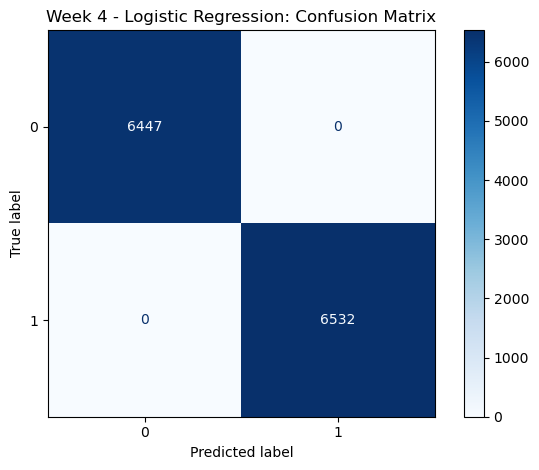

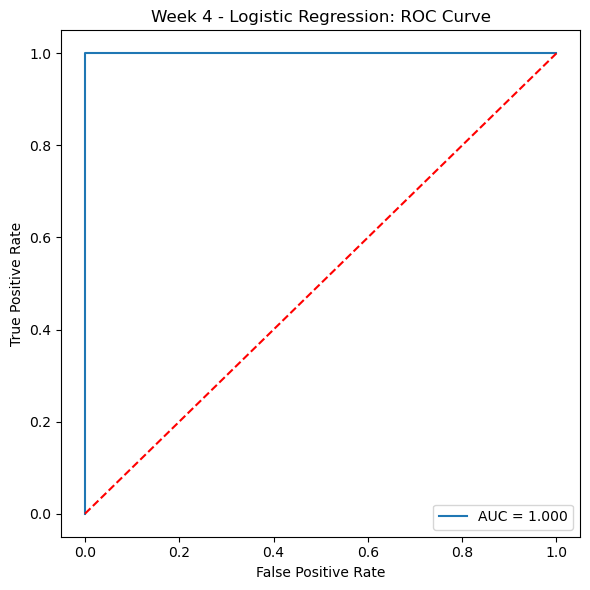

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# Example: if you created a binary target `HighTaxValue`
# and trained logistic regression → got y_pred_log, y_proba_log

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Week 4 - Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.savefig("visuals/week4/log_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)   # y_proba_log = model.predict_proba(X_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Week 4 - Logistic Regression: ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/week4/log_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l

Week 4 — Logistic: Accuracy=0.503 | ROC AUC=0.500
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6447
           1       0.50      1.00      0.67      6532

    accuracy                           0.50     12979
   macro avg       0.25      0.50      0.33     12979
weighted avg       0.25      0.50      0.34     12979



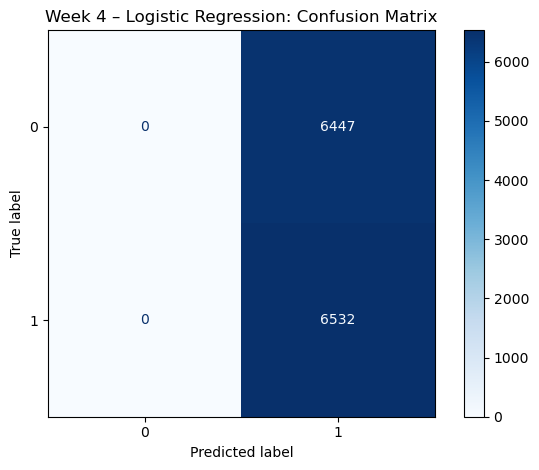

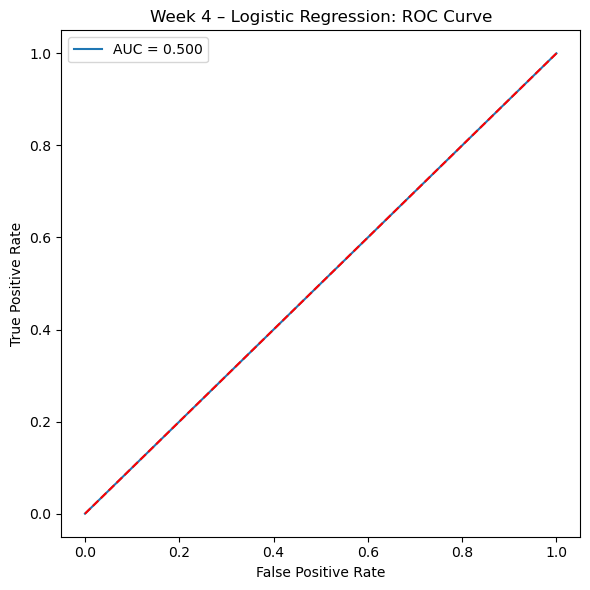

Week 4 — Logistic CV ROC AUC (5-fold): 0.770


In [4]:

import os, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, accuracy_score, classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score

os.makedirs("visuals/week4", exist_ok=True)

# Re-create logistic regression model with preprocessing pipeline
try:
    log_model
except NameError:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    import numpy as np

    num_cols = X_train.select_dtypes(include=[np.number]).columns
    pre_log = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols)
    ], remainder="drop")
    log_model = Pipeline([("pre", pre_log),
                          ("clf", LogisticRegression(max_iter=1000))])
    log_model.fit(X_train, y_train)

# predictions & scores
y_pred_log  = log_model.predict(X_test)
# prefer predict_proba for ROC
if hasattr(log_model, "predict_proba"):
    y_proba_log = log_model.predict_proba(X_test)[:, 1]
else:
    # fallback to decision_function if needed
    y_proba_log = log_model.decision_function(X_test)

acc = accuracy_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_proba_log)
print(f"Week 4 — Logistic: Accuracy={acc:.3f} | ROC AUC={auc:.3f}")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix (save)
cm = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", values_format="d")
plt.title("Week 4 – Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.savefig("visuals/week4/log_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# ROC Curve (save)
fpr, tpr, _ = roc_curve(y_test, y_proba_log)
roc_auc = roc_auc_score(y_test, y_proba_log)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Week 4 – Logistic Regression: ROC Curve"); plt.legend()
plt.tight_layout()
plt.savefig("visuals/week4/log_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# Light CV to satisfy "CV present"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(log_model, X_train, y_train, cv=cv, scoring="roc_auc").mean()
print(f"Week 4 — Logistic CV ROC AUC (5-fold): {cv_auc:.3f}")